### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from figure_rendering import (
    render_cluster_panel,
    plot_deformation_comparison_clean,
    export_cell_shape_pngs,
    CELL_SHAPE_KINDS,
)

### Folders

In [2]:
CONFIGS = "CONFIGS/CONFIGS/"
OVER_DATA    = "NEW_FIGURE_DATA/"

### Render settings

In [3]:
# --- Voronoi edge styling (cell-cell borders only) ---
VORONOI_EDGE_SETTINGS = {
    "voronoi_edge_mode": "intercell",
    "voronoi_edge_color": "#000000",
    "voronoi_edge_width": 2.5,
}

COLOR_SETTINGS = {
    "cmap": "plasma",
    "cmin": 30,
    "cmax": None,
    "bright_near_camera": True,  # False flips: far cells become brighter
}

### Figure 1 - Active wedging

In [5]:
# --- Voronoi edge styling (cell-cell borders only) ---
VORONOI_EDGE_SETTINGS = {
    "voronoi_edge_mode": "intercell",
    "voronoi_edge_color": "#000000",
    "voronoi_edge_width": 2.5,
}

COLOR_SETTINGS = {
    "cmap": "plasma",
    "cmin": 30,
    "cmax": None,
    "bright_near_camera": True,  # False flips: far cells become brighter
}

settings={**COLOR_SETTINGS, **VORONOI_EDGE_SETTINGS, "border_cap": 2.0,
                    "edge_width": 1.0, "voronoi_edge_width": 5.0,  "show_voronoi_edges": True, "neighbor_search_factor": 2.5}

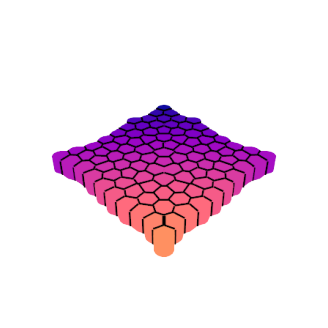

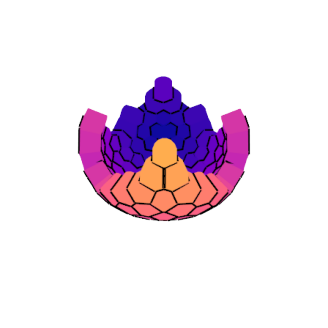

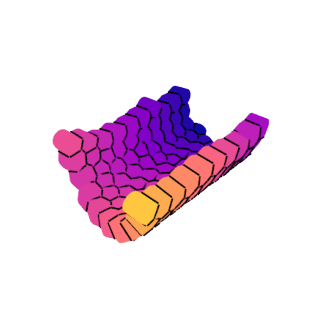

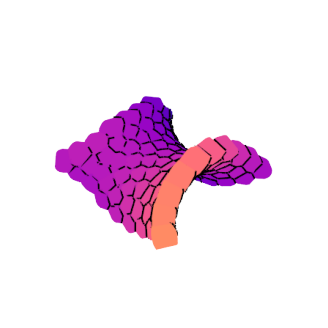

In [ ]:
SAVE_FOLDER = "NEW_FIGURES/FIG1/"
DATA = OVER_DATA + "FIG1/"

bc      = np.load(CONFIGS + "sheet_1010_frame.pkl", allow_pickle=True)
iso     = np.load(DATA + "par_20.0_perp_20.0/data.pkl", allow_pickle=True)
aniso   = np.load(DATA + "par_20.0_perp_0/data.pkl", allow_pickle=True)
pringle = np.load(DATA + "par_20.0_perp_-20.0/data.pkl", allow_pickle=True)
lst     = [bc, iso, aniso, pringle]
lst_names = ["basecase", "iso", "aniso", "pringle"]

for i, config in enumerate(lst):
    if lst_names[i] == 'basecase':    
        img = render_cluster_panel(
            config["x"],
            p=config["p"],
            mode="voronoi",  # or "sphere"
            settings=settings,
        )
    else:
        img = render_cluster_panel(
            config["x"][-1],
            p=config["p"][-1],
            mode="voronoi",  # or "sphere"
            settings=settings,
        )
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(img)
    ax.axis("off")
    name = lst_names[i]
    fig.savefig(SAVE_FOLDER + name + ".png", dpi=400, transparent=True, bbox_inches="tight")


### Figure 2 - Active extension/contraction

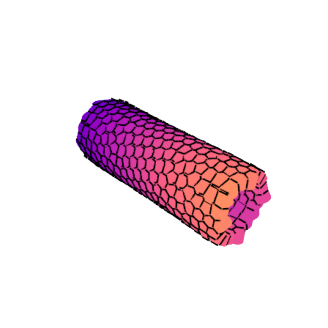

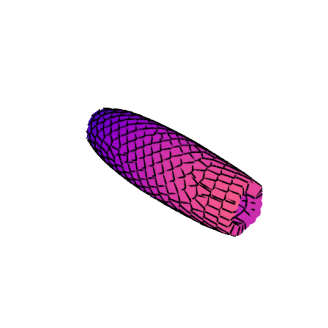

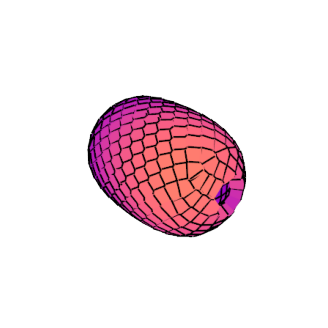

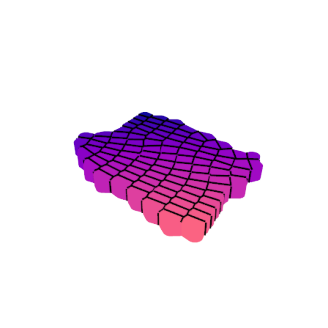

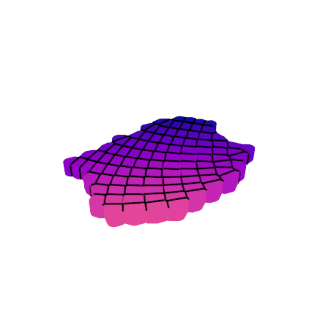

In [24]:
FIG2_COLOR_SETTINGS = {
    "cmap": "plasma",
    "cmin": 50,
    "cmax": None,
    "bright_near_camera": True,  # False flips: far cells become brighter
}

cylinder_settings={**FIG2_COLOR_SETTINGS, **VORONOI_EDGE_SETTINGS, "border_cap": 2.0,
                    "edge_width": 1.0, "voronoi_edge_width": 5.0,
                      "show_voronoi_edges": True, "neighbor_search_factor": 2.5,
                      "rotation": {"axis": "x", "degrees": 90}}

SAVE_FOLDER = "NEW_FIGURES/FIG2/"
os.makedirs(SAVE_FOLDER, exist_ok=True)
DATA = OVER_DATA + "FIG2/"

bc_cyl  = np.load(CONFIGS + "cylinder_2020_frame.pkl", allow_pickle=True)
cyl_g06 = np.load(DATA + "cylinder_2020_gamma_0.66/data.pkl", allow_pickle=True)
cyl_g15 = np.load(DATA + "cylinder_2020_gamma_1.5/data.pkl", allow_pickle=True)
sheet_g06 = np.load(DATA + "sheet_1010_gamma_0.66/data.pkl", allow_pickle=True)
sheet_g15 = np.load(DATA + "sheet_1010_gamma_1.5/data.pkl", allow_pickle=True)
lst     = [bc_cyl, cyl_g06, cyl_g15, sheet_g06, sheet_g15]
lst_names = ["basecase_cylinder", "cyl_g06", "cyl_g15", "sheet_g06", "sheet_g15"]

for i, config in enumerate(lst):
    if lst_names[i] == 'basecase_cylinder':    
        img = render_cluster_panel(
            config["x"],
            p=config["p"],
            mode="voronoi",  # or "sphere"
            settings=cylinder_settings,
        )
    elif 'cyl' in lst_names[i]:
        img = render_cluster_panel(
            config["x"][-1],
            p=config["p"][-1],
            mode="voronoi",  # or "sphere"
            settings=cylinder_settings,
        )
    else:
        img = render_cluster_panel(
            config["x"][-1],
            p=config["p"][-1],
            mode="voronoi",  # or "sphere"
            settings=settings,
        )
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(img)
    ax.axis("off")
    name = lst_names[i]
    fig.savefig(SAVE_FOLDER + name + ".png", dpi=400, transparent=True, bbox_inches="tight")


### Figure 3 - Reactive wedging

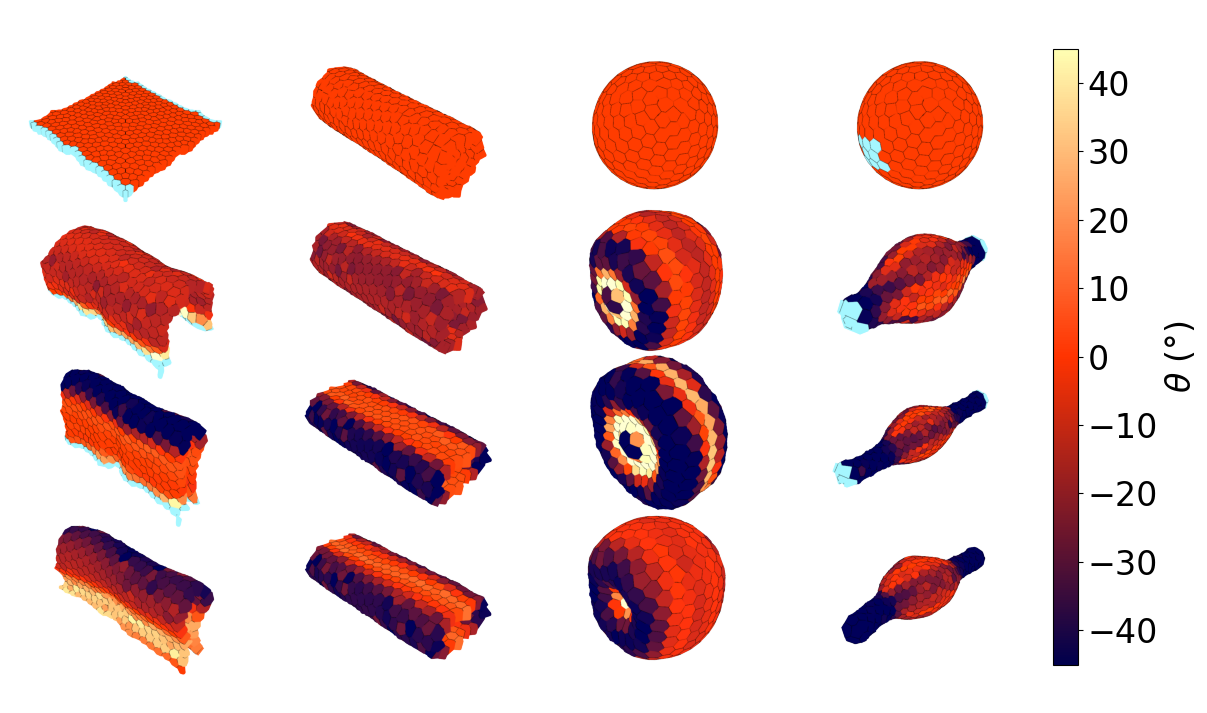

In [4]:
SAVE_FOLDER = "NEW_FIGURES/FIG3/"
os.makedirs(SAVE_FOLDER, exist_ok=True)
DATA = OVER_DATA + "FIG3/"

curve = np.load(DATA + "curved_stretch_2020/data.pkl", allow_pickle=True)
cylinder_sq = np.load(DATA + "cylinder_2020_squeeze/data.pkl", allow_pickle=True)
sphere_sq = np.load(DATA + "sphere_2020_squeeze_screenout_False/data.pkl", allow_pickle=True)
sphere_pu = np.load(DATA + "sphere_2020_stretch/data.pkl", allow_pickle=True)

FIG3_COLUMNS = [
    {
        "key": "curve",
        "scalar": "alpha_perp",
        "frames": [0, 400, 750, 1599],  # Initial / During / Post
        "rotation": None,
        "data": curve,
        "highlight_p_mask": True,
        "panel_scale": 1.5
    },
    {
        "key": "cylinder_sq",
        "scalar": "alpha_perp",
        "frames": [0, 400, 800, 1599],
        "rotation": {"axis": "x", "degrees": 90},
        "data": cylinder_sq,
        "panel_scale": 1.5
    },
    {
        "key": "sphere_sq",
        "scalar": "alpha_perp",
        "frames": [0, 400, 800, 1599],
        "rotation": None,
        "data": sphere_sq,
        "panel_scale": 1.5
    },
    {
        "key": "sphere_pu",
        "scalar": "alpha_par",
        "frames": [0, 400, 800, 1599],
        "rotation": None,
        "data": sphere_pu,
        "highlight_p_mask": True,
        "panel_scale": 1.5
    },
]

fig3 = plot_deformation_comparison_clean(
    FIG3_COLUMNS,
    scalar_vmin=-45,
    scalar_vmax=45,
    colorbar_fontsize=24,
    render_settings={
        **VORONOI_EDGE_SETTINGS,
        "border_cap": 1.0,
        "voronoi_edge_width": 2.5,
        "show_voronoi_edges": True,
    },
    output_path= SAVE_FOLDER + "free_alpha_deformation_2.png",
)

### Figure 4 - Reactive extension/contraction

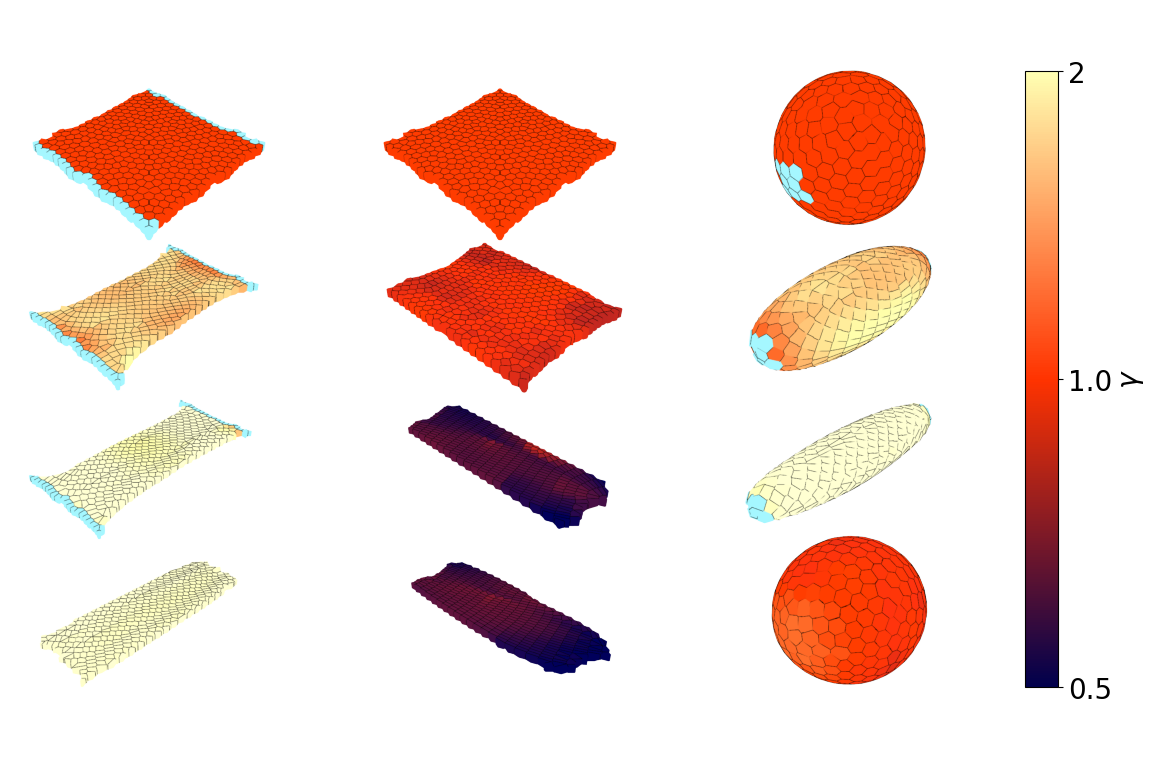

In [5]:
SAVE_FOLDER = "NEW_FIGURES/FIG4/"
os.makedirs(SAVE_FOLDER, exist_ok=True)
DATA = OVER_DATA + "FIG4/"

sheet_sq = np.load(DATA + "sheet_2020_squeeze/data.pkl", allow_pickle=True)
sheet_str = np.load(DATA + "sheet_2020_stretch/data.pkl", allow_pickle=True)
sphere_str = np.load(DATA + "sphere_400_stretch/data.pkl", allow_pickle=True)

FIG3_COLUMNS = [
    {
        "key": "sheet_str",
        "scalar": "gamma",
        "frames": [0, 400, 800, 1599],
        "rotation": None,
        "data": sheet_str,
        "panel_scale": 1.8,
        "highlight_p_mask": True,
    },
    {
        "key": "sheet_sq",
        "scalar": "gamma",
        "frames": [0, 400, 800, 1599],  # Initial / During / Post
        "rotation": None,
        "data": sheet_sq,
        "panel_scale": 1.8
    },
    {
        "key": "sphere_str",
        "scalar": "gamma",
        "frames": [0, 400, 800, 2999],
        "rotation": None,
        "data": sphere_str,
        "panel_scale": 1.8,
        "highlight_p_mask": True
    },
]

fig4 = plot_deformation_comparison_clean(
    FIG3_COLUMNS,
    scalar_vmin=0.5,
    scalar_vmax=2.0,
    colorbar_fontsize=20,
    render_settings={
        **VORONOI_EDGE_SETTINGS,
        "border_cap": 1.0,
        "voronoi_edge_width": 2.5,
        "show_voronoi_edges": True,
        "neighbor_search_factor": 5
    },
    output_path= SAVE_FOLDER + "free_gamma_deformation_2.png",
)

### Figure 5 - Reactive wedging and extension/contraction

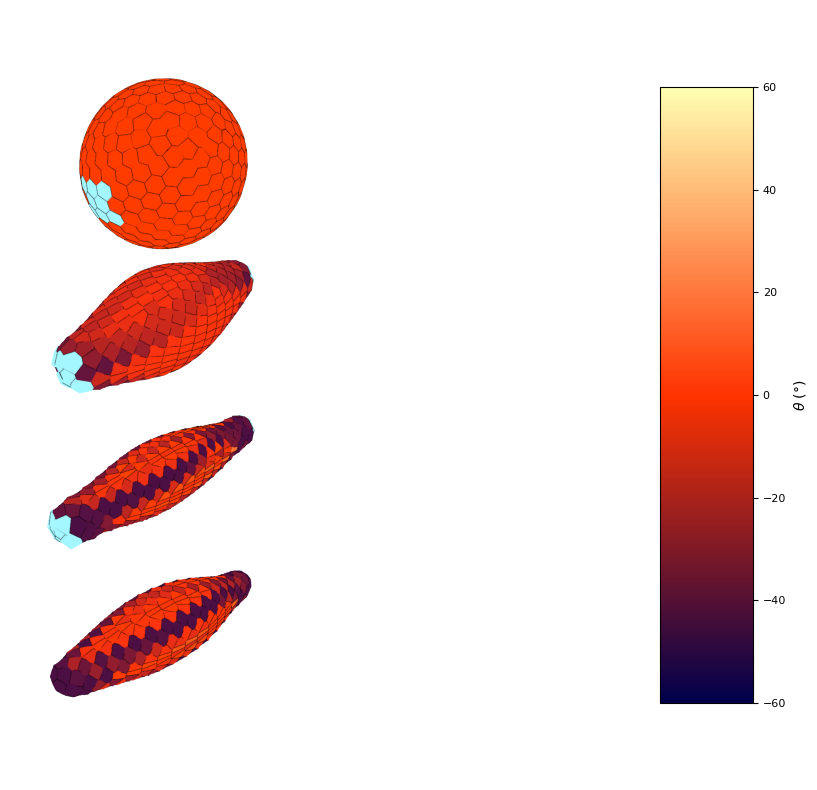

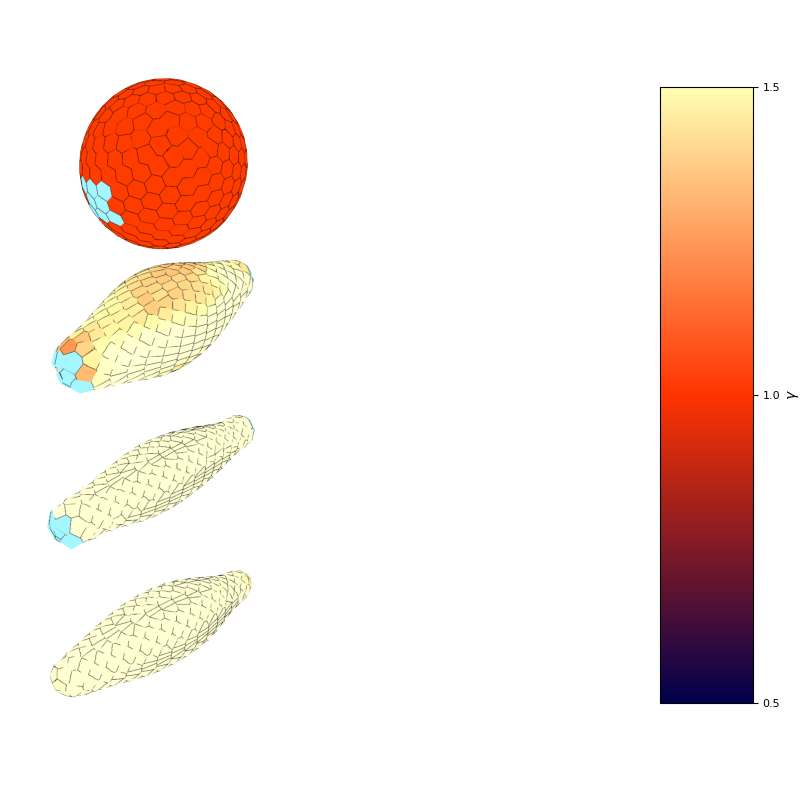

In [ ]:
SAVE_FOLDER = "NEW_FIGURES/FIG5/"
os.makedirs(SAVE_FOLDER, exist_ok=True)
DATA = OVER_DATA + "FIG5/"

sphere_str = np.load(DATA + "sphere_400_bothfree_stretch/data.pkl", allow_pickle=True)

FIG3_COLUMNS = [
    {
        "key": "sphere_str",
        "scalar": "alpha_par",
        "frames": [0, 400, 800, 2999],
        "rotation": None,
        "data": sphere_str,
        "panel_scale": 2.0,
        "highlight_p_mask": True,
    },
]

fig5 = plot_deformation_comparison_clean(
    FIG3_COLUMNS,
    scalar_vmin=-45,
    scalar_vmax=45,
    render_settings={
        **VORONOI_EDGE_SETTINGS,
        "border_cap": 1.0,
        "voronoi_edge_width": 2.5,
        "show_voronoi_edges": True,
        "neighbor_search_factor": 5
    },
    output_path="fig_deformation_comparison_alpha.png",
)

FIG3_COLUMNS = [
    {
        "key": "sphere_str",
        "scalar": "gamma",
        "frames": [0, 400, 800, 2999],
        "rotation": None,
        "data": sphere_str,
        "panel_scale": 2.0,
        "highlight_p_mask": True,
    },
]

fig5 = plot_deformation_comparison_clean(
    FIG3_COLUMNS,
    scalar_vmin=0.5,
    scalar_vmax=2.0,
    render_settings={
        **VORONOI_EDGE_SETTINGS,
        "border_cap": 1.0,
        "voronoi_edge_width": 2.5,
        "show_voronoi_edges": True,
        "neighbor_search_factor": 5
    },
    output_path="fig_deformation_comparison_gamma.png",
)

### Figure additions

In [5]:
# Single-cell 3D shape illustrations — one clean transparent PNG per shape (no text)
SAVE_FOLDER = "NEW_FIGURES/cell_shapes/"
os.makedirs(SAVE_FOLDER, exist_ok=True)

paths = export_cell_shape_pngs(SAVE_FOLDER, settings={"edge_width": 20.0})
for kind, path in paths.items():
    print(f"{kind}: {path}")


column: NEW_FIGURES\cell_shapes\cell_column.png
wedge: NEW_FIGURES\cell_shapes\cell_wedge.png
frustum: NEW_FIGURES\cell_shapes\cell_frustum.png
saddle: NEW_FIGURES\cell_shapes\cell_saddle.png
stretch: NEW_FIGURES\cell_shapes\cell_stretch.png
stretch_rot: NEW_FIGURES\cell_shapes\cell_stretch_rot.png
